# Landmark Detection using TensorFlow

## Dataset
Intel Image Classification Dataset (Kaggle)

## Objective
To classify landmark and scene images using Transfer Learning with VGG19.

## Technologies Used
- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib

In [1]:
import zipfile

zip_path = "/content/intel-image-classification.zip.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/intel_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

for root, dirs, files in os.walk("/content/intel_dataset"):
    print("Folders:", dirs[:10])
    break

Folders: ['seg_train', 'seg_test', 'seg_pred']


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
train_dir = "/content/intel_dataset/seg_train/seg_train"
test_dir = "/content/intel_dataset/seg_test/seg_test"

print("Train Path:", train_dir)
print("Test Path:", test_dir)

Train Path: /content/intel_dataset/seg_train/seg_train
Test Path: /content/intel_dataset/seg_test/seg_test


In [5]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [6]:
print(train_generator.class_indices)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [7]:
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 190ms/step - accuracy: 0.8240 - loss: 0.9453 - val_accuracy: 0.8987 - val_loss: 0.3403


In [11]:
results = model.evaluate(test_generator)

print("Test Accuracy:", results[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9053 - loss: 0.2980
Test Accuracy: 0.9053333401679993


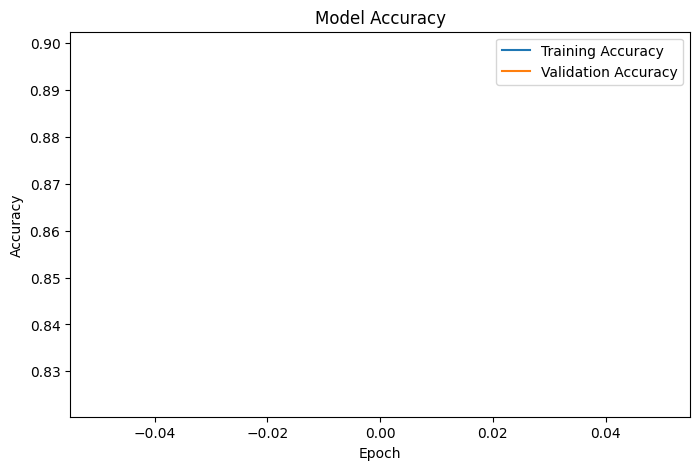

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Conclusion

A Landmark Detection model was developed using the Intel Image Classification Dataset and VGG19 Transfer Learning.

The model was trained to classify images into six categories:
- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

The model achieved:
- Training Accuracy: 82.40%
- Validation Accuracy: 89.87%
- Test Accuracy: 90.53%

These results demonstrate the effectiveness of transfer learning using VGG19 for landmark and scene image classification tasks.